# Fourier Analysis

**Instructor:** Camilla Marcellini - cmarcellini@ucsd.edu
  
**TAs:** Tommy Stone, Sophie Wynn, Argen Smith

Lecture notes adapted from 2025 Math Workshop Notes by Austin Green.


## 1 | Introduction

In previous sections, we were introduced to series expansions as a way to estimate functions. We saw that Taylor Series are a good tool to approximate a function locally, i.e. around some point, and are an example of Power Series. Fourier Series are another type of series expansion applied to  *Periodic* functions, which approximate functions globally.

From an application standpoint, Fourier Analysis is particularly useful because of the prevalence of periodic signals of many natural phenomena that many of us will encounter. Waves are often the most visible form of periodic signals we see in oceanography, but are not the only ones. Fourier analysis is a fairly content-dense topic that a single 1-hour lecture would have a hard time summarizing well, so for the purposes of this workshop, we will focus on building your intuition for approaching these problems.

## 2 | The Fourier Series

### 2.1 Overview
As mentioned before, the Fourier Series is a way of describing a given function through a linear superposition of sine and cosine components, defined as such: 

$$ f(x) = \frac{1}{2} a_0 + \sum_{n=1}^{\infty}a_n\ cos(\frac{n\pi x}{L})+  \sum_{n=1}^{\infty}b_n\ sin(\frac{n\pi x}{L})$$


where L is the period of the function.

This is a concise form of the Fourier Series, but let's take a second to think about this. Here are some checkpoint questions to make sure you understand before we go deeper.

1. **What do the Fourier coefficient terms describe?**
   
     $a_0$, $a_n$ & $b_n$ are the  coefficients which describe the relative weight of each component towards the reconstruction of $f(x)$.

2. **Why do we need a separate cosine and sine term?**

    This comes from a really useful trigonometric identity. We normally might express a wave like this: $f(x) = cos(kx + \phi)$ or $f(t) = cos(\omega t + \phi)$. This details a wave that is either space ($kx$) or time ($\omega t$) varying, with a phase offset term. That phase offset is the part that we care about in this instance, and the reason we end up needing both components. If we use the trig identity $cos(A + B) = cos(A)cos(B) - sin(A)sin(B)$, we can accurately represent the phase of a single wave mode, with a zero phase sine and cosine component instead.

3. **What are the bounds of the interval as written?**

   In this particular case, the bounds are over all values of $0 \le n \le \infty$. This means we are summing over an infinite number of harmonics, i.e. the 0th, 1st, 2nd, term and so on.

### 2.2 Periodicity

As a very quick refresher, a function is considered periodic if $ f(x+L) = f(x)$ for all values of x, where L is the period (spatially) or $f(t+T) = f(t)$ for all t, where T is the period (temporally). The period is inversely proportional to the frequency( or wavenumber) of our waves. i.e. $T = \frac{1}{f}$ or $L = \frac{1}{x}$.

**Exercise 1: What is the Period of sin(t)?**

- **Recall:** we define a time varying wave as $sin(\omega t)$, where $\omega = 2\pi \ f$
- This means that $sin(t) = sin(\omega t)$, when $\omega = 1$. Then $\omega = 2\pi \ f = 1$, so $f = \frac{1}{2\pi}$.
- Since the frequency is $\frac{1}{2\pi}$, $T = 2\pi$.
- $sin(t)$ is periodic over a period of $2\pi$.  

For higher frequencies, it should then track that our period gets smaller as well. Making a general case for this, we get the expression $cos(\frac{n\pi x}{L})$ which has a period of $\frac{2L}{n}$.


### 2.3 Orthogonality

Now that we have our final form of the series, how do we go about solving for the $a_n$ and $b_n$ terms? We'll start by looking at the orthogonality integrals of one of these Fourier modes. 

$$\int^L_{-L}cos(\frac{m\pi x}{L})cos(\frac{n\pi x}{L}) dx = \left\{ 
\begin{array}{ll}
    2L & m = n =0 \\
    L & m = n\ne0 \\
    0 & m\ne n 
    
\end{array}
\right.$$


$$\int^L_{-L}sin(\frac{m\pi x}{L})sin(\frac{n\pi x}{L}) dx = \left\{ 
\begin{array}{ll}
    L & m = n \geq 1 \\
    0 & m\ne n 
\end{array}
\right.$$


$$\int^L_{-L}cos(\frac{2m\pi x}{L})sin(\frac{2n\pi x}{L}) dx = 0$$ 

Computing these integrals should be relatively straight forward, and easy to verify. However, in case it does not immediately track in your brain as to why this works out here is a handy little demo to visually show you. 

The final bit of all this is actually solving for those $a_n$ & $b_n$ terms. If we rearrange our original expression, we get something that looks like this

$$ a_n = \frac{1}{L} \int^L_{-L} f(x)\ cos(\frac{n\pi x}{L})dx$$
$$ b_n = \frac{1}{L} \int^L_{-L} f(x)\ sin(\frac{n\pi x}{L})dx$$

### 2.4  Examples and Exercises

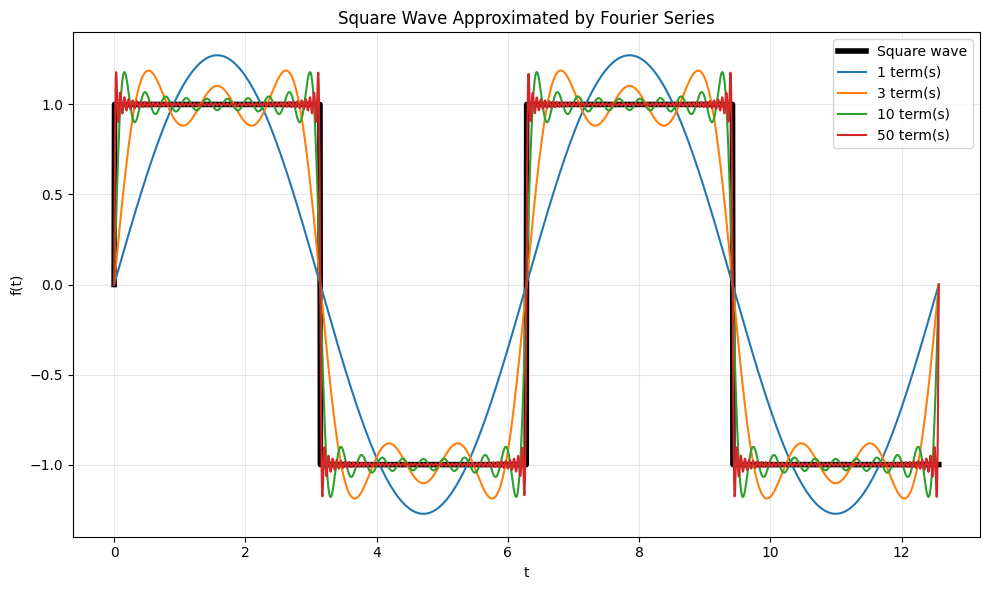

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def square_wave(t, T=2*np.pi, amplitude=1.0):
    """
    Ideal square wave with period T.
    Returns +amplitude for the first half of each period, -amplitude for the second half.
    """
    return amplitude * np.sign(np.sin(2 * np.pi * t / T))

def square_wave_fourier(t, n_terms, T=2*np.pi, amplitude=1.0):
    """
    Fourier series approximation of a square wave using n_terms odd harmonics.

    A square wave's Fourier series only has odd harmonics:
        f(t) = (4A/pi) * sum_{k=1,3,5,...} (1/k) * sin(2*pi*k*t/T)
    """
    result = np.zeros_like(t)
    for k in range(1, 2 * n_terms, 2):  # odd harmonics: 1, 3, 5, ...
        result += (1 / k) * np.sin(2 * np.pi * k * t / T)
    return (4 * amplitude / np.pi) * result

T = 2 * np.pi
t = np.linspace(0, 2 * T, 2000)

ideal = square_wave(t, T)

plt.figure(figsize=(10, 6))
plt.plot(t, ideal, 'k', linewidth=4, label='Square wave')

for n_terms in [1, 3, 10, 50]:
    approx = square_wave_fourier(t, n_terms, T)
    plt.plot(t, approx, label=f'{n_terms} term(s)')

plt.title('Square Wave Approximated by Fourier Series')
plt.xlabel('t')
plt.ylabel('f(t)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Exercise 2:** find $a_n$ & $b_n$ when $f(x) = 1 + 2sin(kx) + 3 cos(3kx)$

1. Start with
$$ a_n = \frac{1}{L} \int^L_{-L} f(x)\ cos(\frac{n\pi x}{L})dx$$

2. Plug in $f(x)$
$$ a_n = \frac{1}{L} \int^L_{-L} [1 + 2sin(kx) + 3 cos(3kx)] * cos(\frac{n\pi x}{L})dx$$

3. Simplify

$$ a_n = \frac{1}{L} \int^L_{-L} [cos(\frac{n\pi x}{L}) + 2sin(kx)*cos(\frac{n\pi x}{L}) + 3 cos(3kx)*cos(\frac{n\pi x}{L})]dx$$

$$ a_n = \frac{1}{L} \int^L_{-L} [cos(\frac{n\pi x}{L}) + 3 cos(3kx)*cos(\frac{n\pi x}{L})]dx$$

$$ a_0 = \frac{1}{L} \int^L_{-L} [1]dx = \frac{2L}{L} = 2$$

$$ a_6 = \frac{1}{L} \int^L_{-L}  3 cos(3kx)*cos(\frac{n\pi x}{L})dx = \frac{3L}{L}  = 3$$

**Exercise 3:** find $a_n$ & $b_n$ when $f(x) = 4cos(kx) - 4sin(kx) + 6 cos(10kx)$



### 2.5 Circling back to Euler's formula

In the *Complex Numbers* lecture, we introduced the identity: 
$$ e^{i\theta} = cos(\theta) + i\ sin(\theta)$$

This then gets expanded to the idea of the unit circle, where the x axis (Real axis) is represented by cosine terms, and the y axis (Imag axis) is represented by sine terms. We often use this form to represent circular or wave-like motions. 

If we use this identity, we can redefine our expression of the Fourier series, to something that looks like this.

$$ x(t) = \sum_{k = -\infty}^{\infty}c_k e^{(i2\pi kt)/T} =  \sum_{k = -\infty}^{\infty}c_k e^{(i\omega_kt)}$$

where $$ \omega _k= \frac{2 \pi }{T}k $$ and the complex coefficient is:

$$ c_k = \frac{1}{T} \int_{0}^{T} x(t)\, e^{-i \omega _k t} \, dt $$

Essentially, this just shifts our from of reference from individual sines and cosines at a specific frequency, and puts it into terms of circles instead. This also transitions us nicely into the next idea, which is the Fourier Transform.

## 3 | Fourier Transforms
The Fourier Transform (FT) is the next step past the series. 

There are typically 2 flavors of the FT that exist, and it is dependent on the type of signal you have. The first option is the continuous Fourier transform (CFT), which is reliant on having a continuous data stream that can be broken up into an infinite number of discrete frequencies. The other option is the discrete Fourier transform (DFT), which is tailored toward discrete data and frequencies. In science, we will mostly utilize the DFT, since this is more like how our sampled signals will actually look like a set of discrete data points, spaced by a uniform (ideally) time step that is defined by our sensors.

### 3.1 The Continuous Fourier Transform (CFT)

The Fourier transform operates on much of the same principles as the Fourier series, but instead of the summation of a bunch of discrete frequency values, what if we just integrated over **ALL** frequency values? You would end up with something like this. (which just so happens to be the definition of the CFT)

$$ x(t) = \int^{\infty}_{-\infty} \tilde{X}(f) e^{i f t} df $$

$$ \tilde{X}(f) = \int^{\infty}_{-\infty} x(t) e^{-i f t} dt $$



### 3.2 The Discrete Fourier Transform

We will not dive much into this type of FT, as it gets more complicated. Luckly, we will never have to compute this ourselves, and we can rely on our beloved algorithms to do the work for us. One of the most used ones is the Fast Fourier Transform (FFT).

## 4 | Real World Applications

As mentioned previously, we often come across regularly repeating signals in all parts of oceanography, with oscillatory fluctuations. For instance, solar radiation varies on a 24 hour cycle, and ocean tides on a semidiurnal (12.42 hour) and diurnal (24.83 hour) cycle. FT work extremely effective with oscillatory signals. Thus, we use the FT to get a sense of what sort of frequencies of things we are seeing, and their strenght, i.e. how they contribute to the measured signal.

The FT can be massaged into a more usuable form, that we call the Spectrum. These can exist in many forms, and can be used to track velocity, energy, temperature, pressure, etc. and is usually in either the wavenumber of frequency domain. 

Here is an example of how we can apply FT to the dynamics in our frontyard.

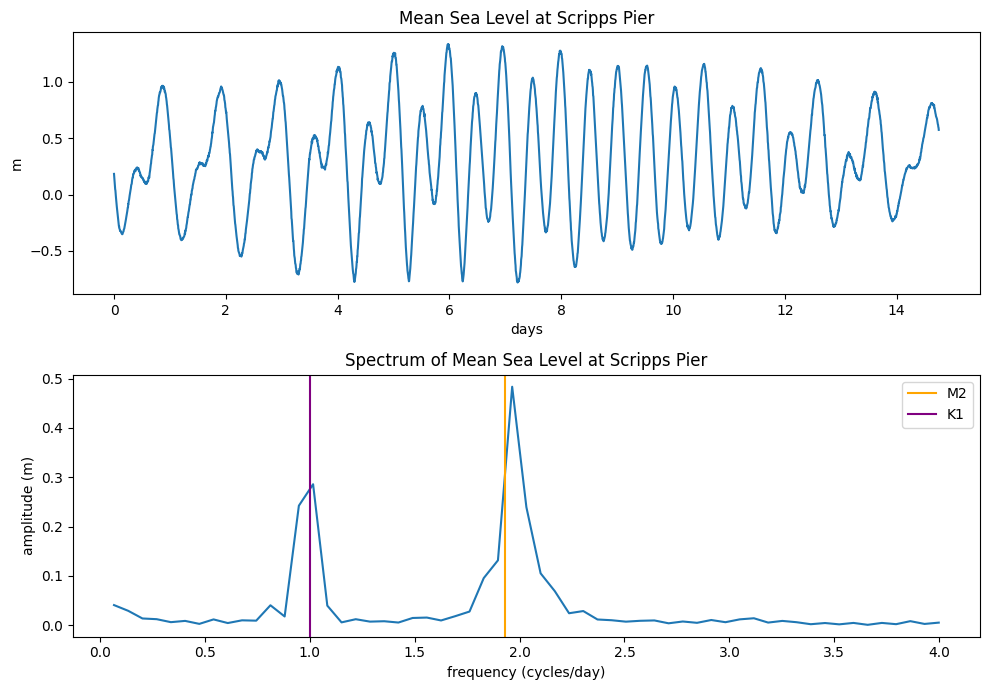

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("/Users/camillamarcellini/Desktop/CODINGSTUFF/MATHWORKSHOP/tides.csv")
level = pd.to_numeric(df["Preliminary (m)"], errors="coerce")
df = df[level.notna()].reset_index(drop=True)
level = level.dropna().values

dt = 6/60
t = np.arange(len(level)) * dt

sig = level - np.mean(level)
spectrum = np.fft.rfft(sig)
freqs = np.fft.rfftfreq(len(sig), d=dt)
amp = (2/len(sig)) * np.abs(spectrum)
cpd = freqs * 24

fig, ax = plt.subplots(2, 1, figsize=(10, 7))
ax[0].plot(t/24, level)
ax[0].set_xlabel("days")
ax[0].set_ylabel("m")
ax[0].set_title('Mean Sea Level at Scripps Pier')

mask = (cpd > 0) & (cpd < 4)
ax[1].plot(cpd[mask], amp[mask])
ax[1].axvline(1.93227361, color='orange', label='M2')
ax[1].axvline(1.00273791, color='purple', label='K1')
ax[1].set_xlabel("frequency (cycles/day)")
ax[1].set_ylabel("amplitude (m)")
ax[1].set_title('Spectrum of Mean Sea Level at Scripps Pier')
ax[1].legend()

plt.tight_layout()
plt.show()